In [1]:
!pip install spectralexplain

In [12]:
import spectralexplain as spex
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import r2_score
import pickle
import os

# Publication-ish defaults scaled up so each two-panel strip stays legible after
# placing two exported figures side-by-side at ~half page width each (~3.35–3.5 in).
NEURIPS_RC = {
    "figure.dpi": 180,
    "savefig.dpi": 400,
    "font.family": "DejaVu Sans",
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.05,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "grid.linewidth": 0.55,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
}

mpl.rcParams.update(NEURIPS_RC)

In [20]:
def display_time(name, time, rmax=True, save_path=None):
    rmax_str = "" if rmax else "_max=False"
    dir = "DRAKES/drakes_protein/fmif/eval_results/spex/"
    cand_a = os.path.join(dir, f"fourier_dict_{time}.pkl")
    cand_b = os.path.join(dir, f"fourier_dict__{name}_{time}.pkl")
    pkl_path = cand_a if os.path.isfile(cand_a) else cand_b
    fourier_dict = pickle.load(open(pkl_path, "rb"))
    heldout_masks = np.loadtxt(dir + f"heldout_masks_{time}{rmax_str}.txt", dtype=int).astype(bool)
    y_true = np.loadtxt(dir + f"y_true_{time}{rmax_str}.txt")
    print("Held out masks shape:", heldout_masks.shape)
    print(f"Successfully loaded experiment: {time}")

    np.random.seed(42)

    def reconstruct_predictions(masks, fdict):
        masks = np.asarray(masks, dtype=bool)
        preds = np.zeros(len(masks), dtype=float)

        for freq, coef in fdict.items():
            active = np.asarray(freq, dtype=bool)
            if not active.any():
                preds += float(coef)
            else:
                parity = masks[:, active].sum(axis=1) % 2
                preds += float(coef) * ((-1) ** parity)

        return preds

    y_pred = reconstruct_predictions(heldout_masks, fourier_dict)
    full_r2 = r2_score(y_true, y_pred)
    print(f"R2 Score on held-out masks: {full_r2:.4f}")

    # Sparsity curve data
    sorted_items = sorted(fourier_dict.items(), key=lambda x: abs(x[1]), reverse=True)
    steps = np.unique(np.geomspace(1, len(sorted_items), num=20, dtype=int))

    k_values = []
    r2_values = []
    for k in steps:
        sparse_dict = dict(sorted_items[:k])
        y_pred_sparse = reconstruct_predictions(heldout_masks, sparse_dict)
        k_values.append(k)
        r2_values.append(r2_score(y_true, y_pred_sparse))

    # Variance decomposition from Fourier coefficients
    energy_by_order = {}
    mean_coef = 0.0

    for key_tuple, coef in fourier_dict.items():
        order = int(sum(key_tuple))
        energy = float(coef) ** 2

        if order == 0:
            mean_coef = float(coef)
        else:
            energy_by_order[order] = energy_by_order.get(order, 0.0) + energy

    total_variance = sum(energy_by_order.values())

    print(f"Mean term c_empty: {mean_coef:.6f}")
    print(f"Mean contribution c_empty^2: {mean_coef**2:.6f}")
    print(f"Total variance from spectrum: {total_variance:.6f}\n")

    print("--- Variance by interaction order ---")
    for order in sorted(energy_by_order):
        perc = 100 * energy_by_order[order] / total_variance if total_variance > 0 else 0.0
        print(f"Order {order}: {energy_by_order[order]:.6f} ({perc:.2f}%)")

    orders = sorted(energy_by_order)
    variances = np.array([energy_by_order[o] for o in orders], dtype=float)
    percentages = 100 * variances / variances.sum() if variances.sum() > 0 else np.zeros_like(variances)

    # Combined figure: variance (left) and sparsity-performance (right), one row.
    # Fig width ~half of a nominal full text column so two proteins sit comfortably
    # side-by-side at \linewidth without shrinking type to microscopic sizes.
    with plt.rc_context(NEURIPS_RC):
        fig_w, fig_h = 8.45, 3.95
        fig, (ax_var, ax_sp) = plt.subplots(
            1, 2, figsize=(fig_w, fig_h), constrained_layout=True
        )

        # Left panel: variance contribution as % of total (by interaction order)
        bars = ax_var.bar(
            orders,
            percentages,
            color="#9ecae1",
            edgecolor="#4a5568",
            linewidth=0.65,
            alpha=0.72,
        )
        ax_var.set_xlabel("Order")
        ax_var.set_ylabel("Var. (%)")
        ax_var.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_var.set_xticks(orders)
        ax_var.grid(True, axis="y")
        ax_var.grid(False, axis="x")
        ax_var.set_axisbelow(True)

        top_pct = float(percentages.max()) if len(percentages) else 0.0
        headroom = max(4.0, 0.14 * top_pct)
        ax_var.set_ylim(0.0, top_pct + headroom)
        dy = max(0.6, 0.025 * (top_pct + headroom))
        for bar, pct in zip(bars, percentages):
            if pct >= 1.0:
                pct_s = f"{pct:.0f}%" if pct >= 10 else f"{pct:.1f}%"
                ax_var.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + dy,
                    pct_s,
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    color="#334155",
                )

        # Right panel: R² vs truncated spectrum (no legend; line styles distinguish curves)
        # Line only first so markers (especially near R²=0) are not buried under segments.
        ax_sp.plot(
            k_values,
            r2_values,
            linestyle="-",
            linewidth=2.15,
            color="#1f77b4",
            marker=None,
            zorder=2,
        )
        ax_sp.axhline(
            full_r2,
            color="#d62728",
            linestyle="--",
            linewidth=1.85,
            zorder=3,
        )
        ax_sp.scatter(
            k_values,
            r2_values,  
            s=42,
            facecolors="#1f77b4",
            edgecolors="white",
            linewidths=1.2,
            zorder=5,
            clip_on=False,
        )
        ax_sp.set_xscale("log")
        ax_sp.set_ylim(0, 1.02)
        ax_sp.set_xlabel("# Coef.")
        ax_sp.set_ylabel(r"$R^2$")
        ax_sp.grid(True, which="major")
        ax_sp.grid(True, which="minor", alpha=0.18)
        ax_sp.set_axisbelow(True)

        fig.set_constrained_layout_pads(w_pad=0.12, h_pad=0.12, rect=(0.01, 0, 0.99, 0.92))
        fig.suptitle(name, y=1.028, fontsize=21, fontweight="normal")
        if save_path is not None:
            fig.savefig(save_path, format="pdf")
            plt.show()
            plt.close(fig)
        else:
            plt.show()


Held out masks shape: (1024, 52)
Successfully loaded experiment: 20260427-181741
R2 Score on held-out masks: 0.9039
Mean term c_empty: 0.564464
Mean contribution c_empty^2: 0.318620
Total variance from spectrum: 0.004341

--- Variance by interaction order ---
Order 1: 0.003399 (78.30%)
Order 2: 0.000755 (17.39%)
Order 3: 0.000156 (3.58%)
Order 4: 0.000028 (0.64%)
Order 5: 0.000004 (0.09%)


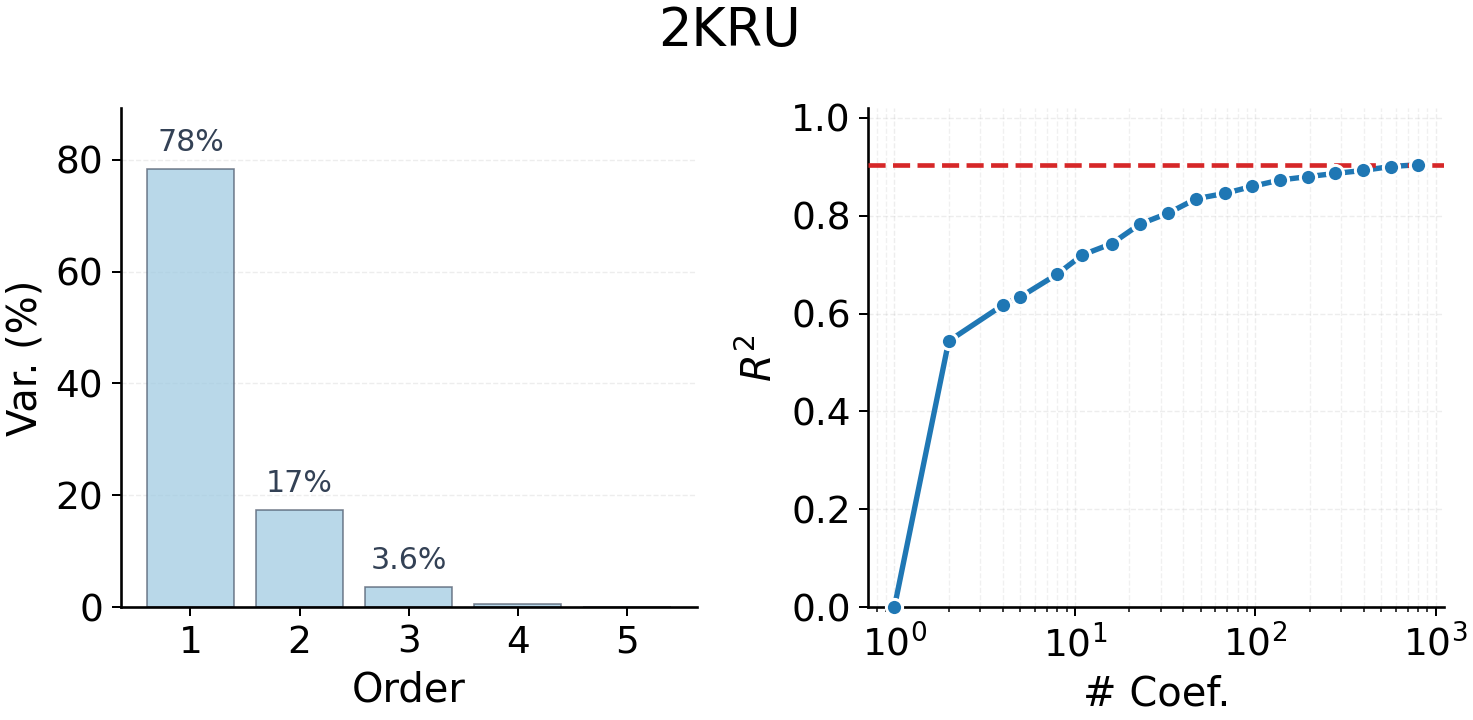

Held out masks shape: (1024, 56)
Successfully loaded experiment: 20260427-191217
R2 Score on held-out masks: 0.8505
Mean term c_empty: 0.526572
Mean contribution c_empty^2: 0.277278
Total variance from spectrum: 0.003713

--- Variance by interaction order ---
Order 1: 0.001549 (41.70%)
Order 2: 0.001414 (38.09%)
Order 3: 0.000624 (16.82%)
Order 4: 0.000113 (3.05%)
Order 5: 0.000013 (0.35%)


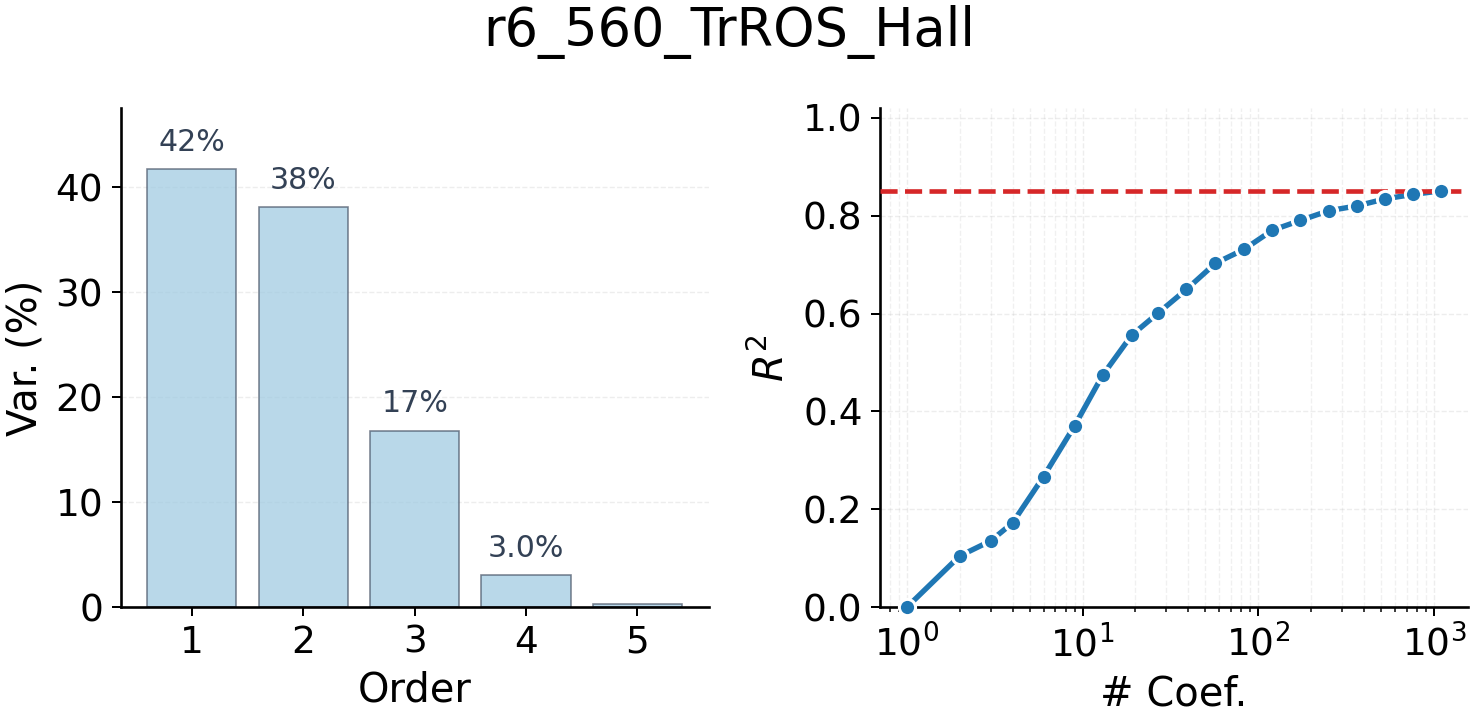

Wrote PDFs to /home/shai/NeuripsProtein2026/Figures


In [21]:
OUT = os.path.expanduser("~/NeuripsProtein2026/Figures")
os.makedirs(OUT, exist_ok=True)

times = ['20260427-181741', '20260427-191217']
# 2KRU: 20260427-181741
# R6-Hall: 20260427-191217, the rest
names = {time : "r6_560_TrROS_Hall" for time in times}
names['20260427-181741'] = "2KRU"

save_paths = {
    "20260427-181741": os.path.join(OUT, "2kru_spex_merged.pdf"),
    "20260427-191217": os.path.join(OUT, "r6_560_trros_hall_spex_merged.pdf"),
}

for time in times:
    display_time(names[time], time, save_path=save_paths[time])
print("Wrote PDFs to", OUT)

In [5]:
# display_time('2L09', '20260428-100017', rmax=False)

Held out masks shape: (1024, 66)
Successfully loaded experiment: 20260428-013719
R2 Score on 1000 held-out masks: 0.7886


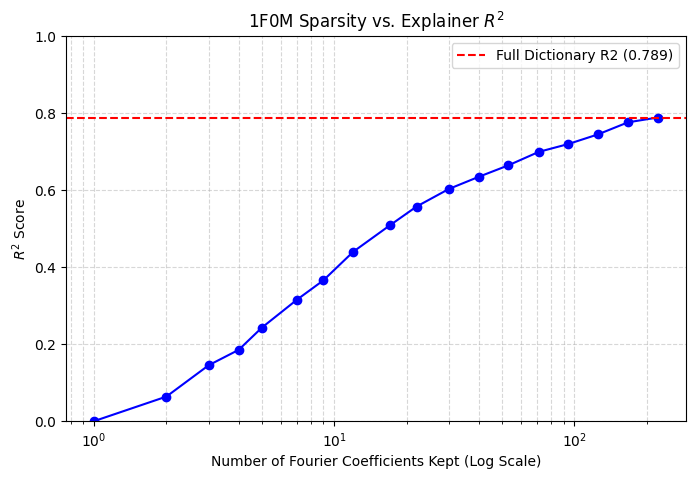

Mean term c_empty: 0.783386
Mean contribution c_empty^2: 0.613694
Total variance from spectrum: 0.000531

--- Variance by Interaction Order ---
Order 1: 0.000393 (74.02%)
Order 2: 0.000111 (20.91%)
Order 3: 0.000025 (4.71%)
Order 4: 0.000002 (0.36%)


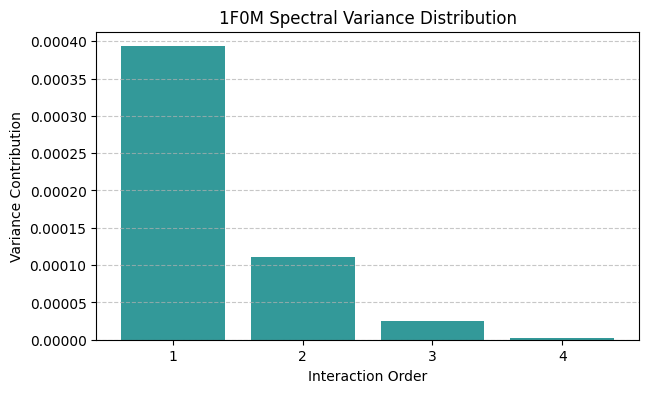

Held out masks shape: (1024, 52)
Successfully loaded experiment: 20260428-043722
R2 Score on 1000 held-out masks: 0.8459


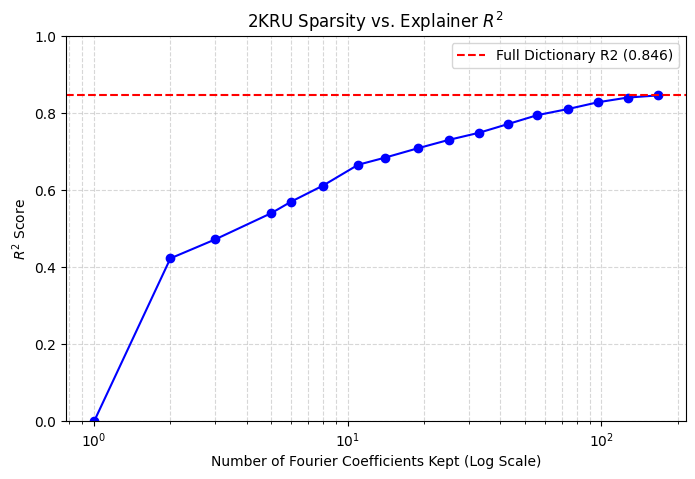

Mean term c_empty: 0.547048
Mean contribution c_empty^2: 0.299262
Total variance from spectrum: 0.004493

--- Variance by Interaction Order ---
Order 1: 0.003452 (76.82%)
Order 2: 0.000881 (19.60%)
Order 3: 0.000142 (3.17%)
Order 4: 0.000013 (0.28%)
Order 5: 0.000006 (0.13%)


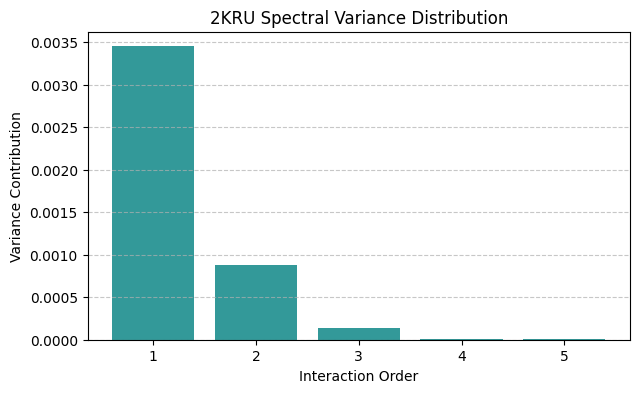

Held out masks shape: (1024, 52)
Successfully loaded experiment: 20260428-012947
R2 Score on 1000 held-out masks: 0.6611


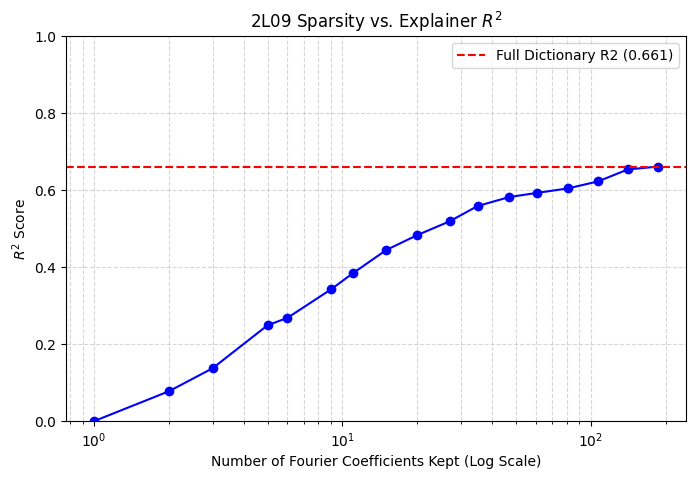

Mean term c_empty: 0.267521
Mean contribution c_empty^2: 0.071567
Total variance from spectrum: 0.004081

--- Variance by Interaction Order ---
Order 1: 0.002124 (52.05%)
Order 2: 0.001355 (33.19%)
Order 3: 0.000524 (12.83%)
Order 4: 0.000079 (1.93%)


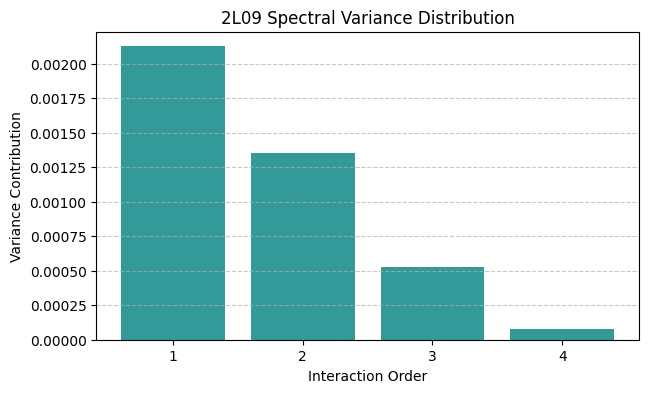

Held out masks shape: (1024, 46)
Successfully loaded experiment: 20260428-030742
R2 Score on 1000 held-out masks: 0.8456


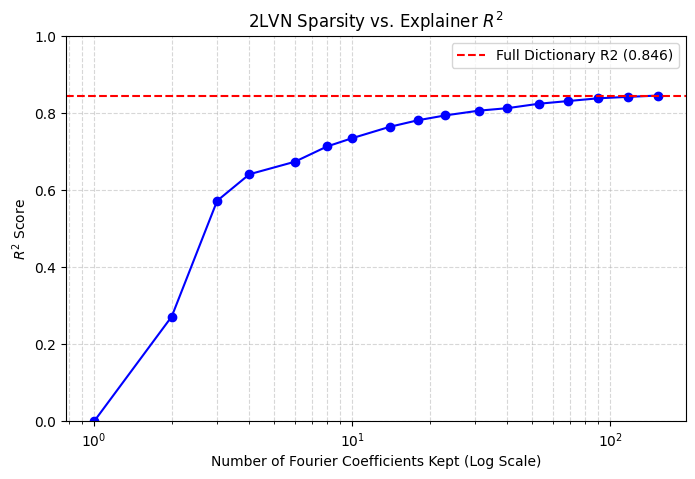

Mean term c_empty: 0.222463
Mean contribution c_empty^2: 0.049490
Total variance from spectrum: 0.027797

--- Variance by Interaction Order ---
Order 1: 0.014723 (52.97%)
Order 2: 0.012072 (43.43%)
Order 3: 0.000859 (3.09%)
Order 4: 0.000144 (0.52%)


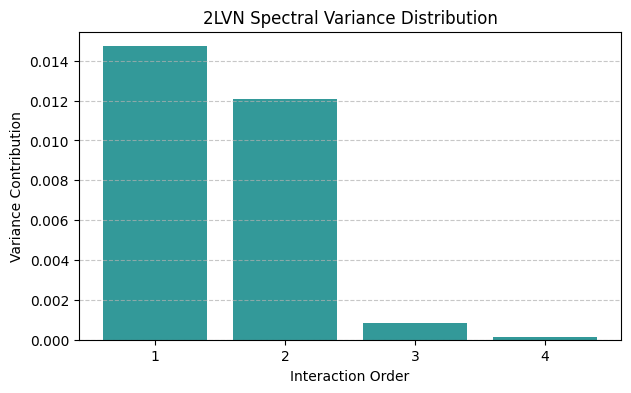

Held out masks shape: (1024, 71)
Successfully loaded experiment: 20260428-023032
R2 Score on 1000 held-out masks: 0.5994


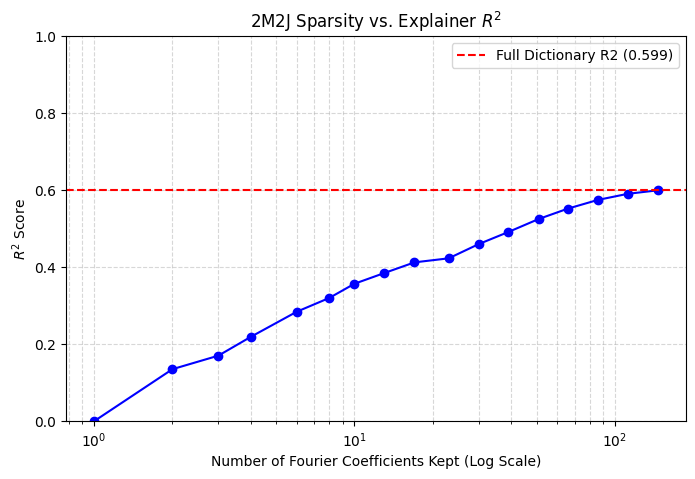

Mean term c_empty: 0.460025
Mean contribution c_empty^2: 0.211623
Total variance from spectrum: 0.010517

--- Variance by Interaction Order ---
Order 1: 0.005853 (55.65%)
Order 2: 0.003828 (36.40%)
Order 3: 0.000821 (7.81%)
Order 4: 0.000015 (0.14%)


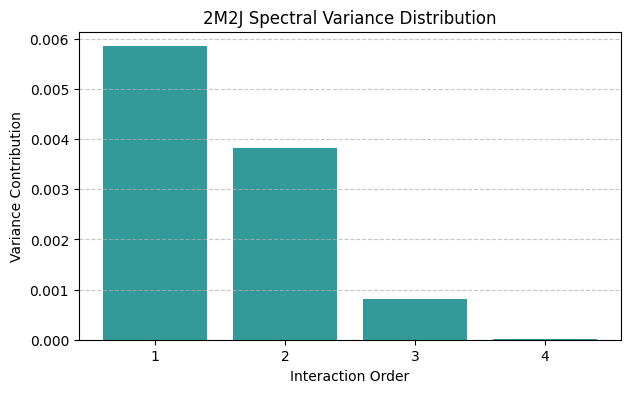

Held out masks shape: (1024, 70)
Successfully loaded experiment: 20260428-034602
R2 Score on 1000 held-out masks: 0.6352


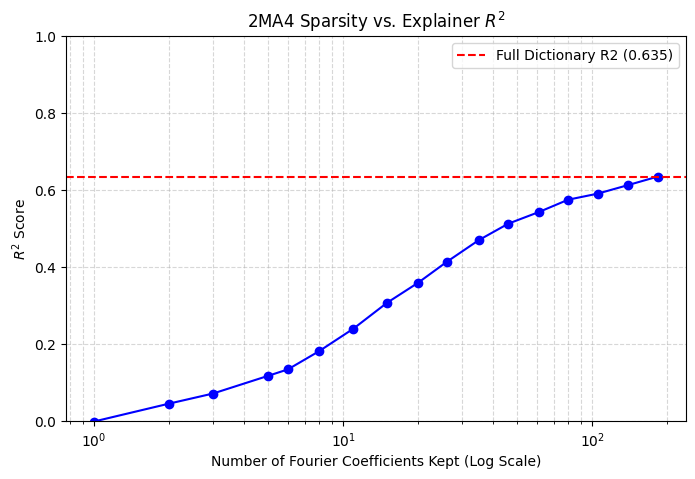

Mean term c_empty: 0.239924
Mean contribution c_empty^2: 0.057564
Total variance from spectrum: 0.014278

--- Variance by Interaction Order ---
Order 1: 0.005495 (38.49%)
Order 2: 0.006467 (45.30%)
Order 3: 0.001879 (13.16%)
Order 4: 0.000235 (1.64%)
Order 5: 0.000201 (1.41%)


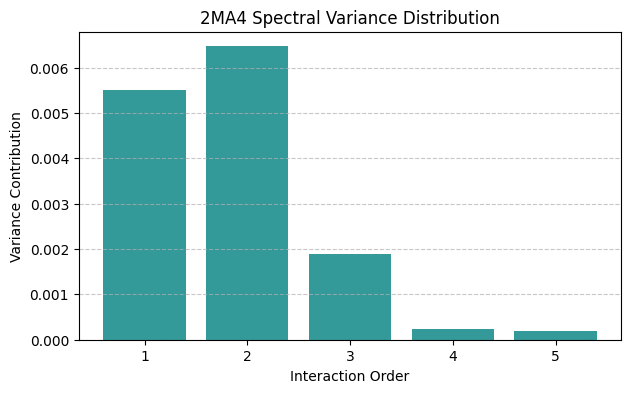

Held out masks shape: (1024, 47)
Successfully loaded experiment: 20260428-021920
R2 Score on 1000 held-out masks: 0.8053


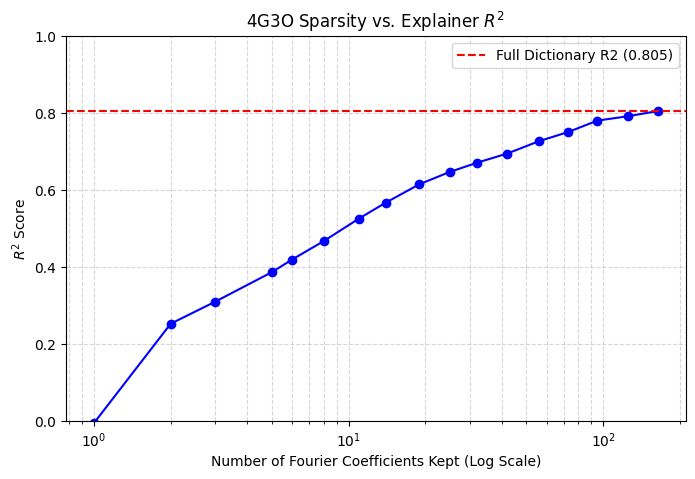

Mean term c_empty: 0.593369
Mean contribution c_empty^2: 0.352086
Total variance from spectrum: 0.013361

--- Variance by Interaction Order ---
Order 1: 0.004321 (32.34%)
Order 2: 0.007191 (53.82%)
Order 3: 0.001489 (11.14%)
Order 4: 0.000330 (2.47%)
Order 5: 0.000031 (0.24%)


Held out masks shape: (1024, 59)
Successfully loaded experiment: 20260428-024054
R2 Score on 1000 held-out masks: 0.8413


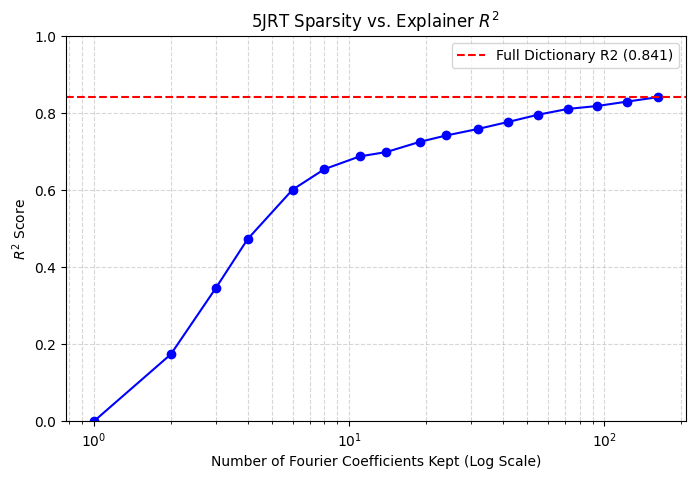

Mean term c_empty: 0.502863
Mean contribution c_empty^2: 0.252872
Total variance from spectrum: 0.002846

--- Variance by Interaction Order ---
Order 1: 0.002014 (70.76%)
Order 2: 0.000725 (25.47%)
Order 3: 0.000101 (3.54%)
Order 4: 0.000006 (0.22%)


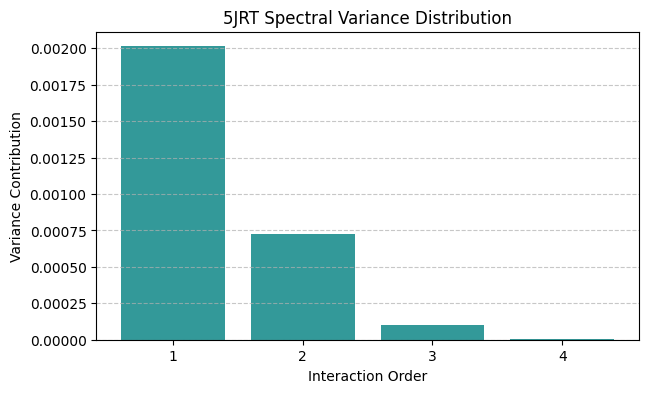

Held out masks shape: (1024, 57)
Successfully loaded experiment: 20260428-034159
R2 Score on 1000 held-out masks: 0.7302


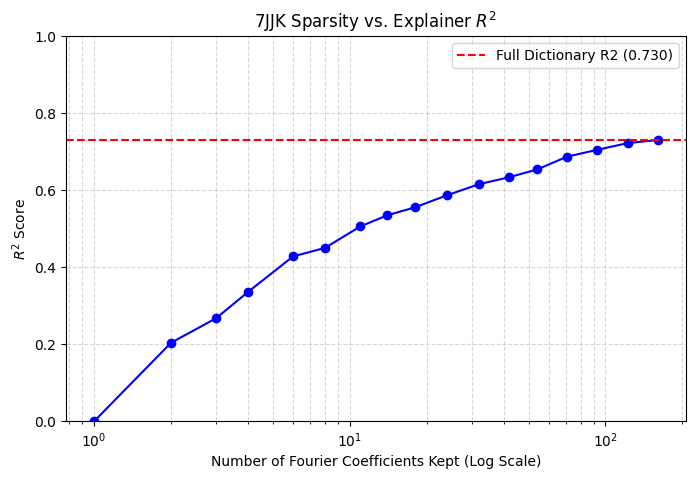

Mean term c_empty: 0.658276
Mean contribution c_empty^2: 0.433327
Total variance from spectrum: 0.001029

--- Variance by Interaction Order ---
Order 1: 0.000653 (63.47%)
Order 2: 0.000294 (28.53%)
Order 3: 0.000058 (5.63%)
Order 4: 0.000023 (2.26%)
Order 5: 0.000001 (0.10%)


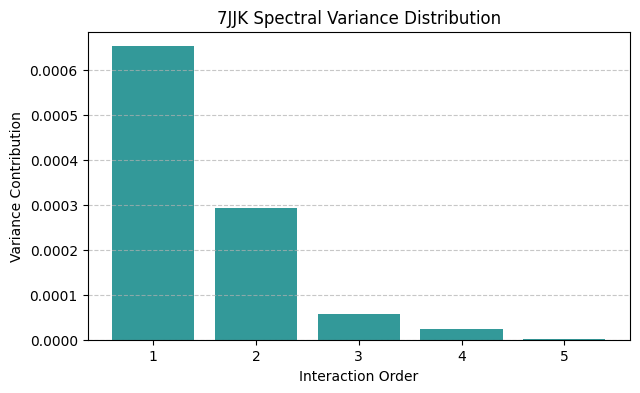

Held out masks shape: (1024, 43)
Successfully loaded experiment: 20260428-011444
R2 Score on 1000 held-out masks: 0.8225


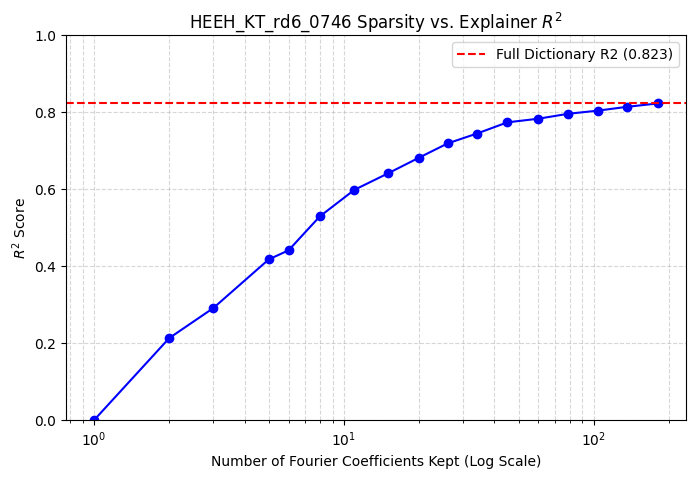

Mean term c_empty: 0.281780
Mean contribution c_empty^2: 0.079400
Total variance from spectrum: 0.017988

--- Variance by Interaction Order ---
Order 1: 0.014153 (78.68%)
Order 2: 0.003128 (17.39%)
Order 3: 0.000583 (3.24%)
Order 4: 0.000105 (0.58%)
Order 5: 0.000019 (0.10%)


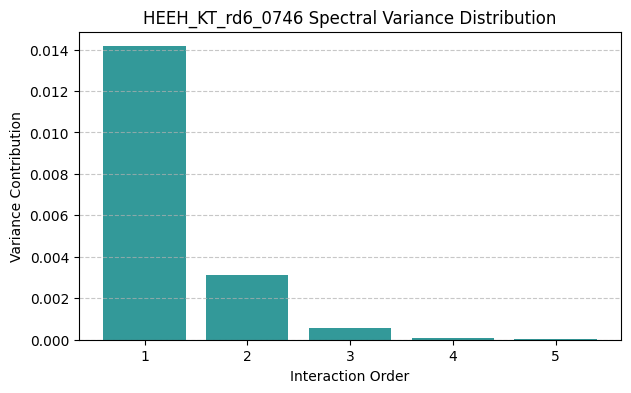

Held out masks shape: (1024, 56)
Successfully loaded experiment: 20260428-002915
R2 Score on 1000 held-out masks: 0.7129


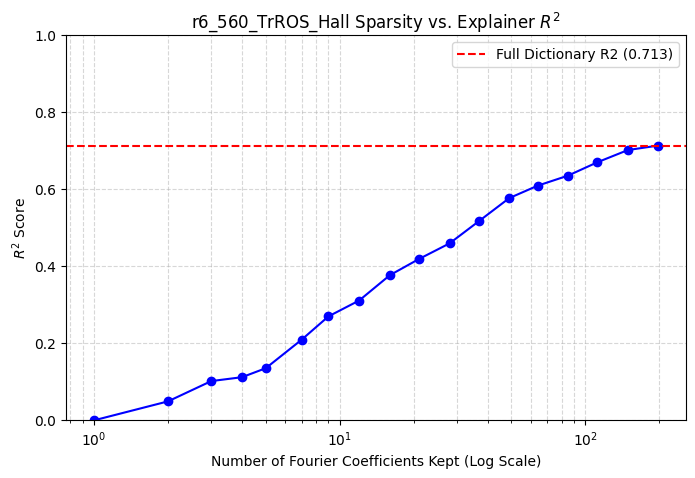

Mean term c_empty: 0.567465
Mean contribution c_empty^2: 0.322017
Total variance from spectrum: 0.001676

--- Variance by Interaction Order ---
Order 1: 0.000701 (41.81%)
Order 2: 0.000614 (36.62%)
Order 3: 0.000302 (18.03%)
Order 4: 0.000054 (3.21%)
Order 5: 0.000005 (0.32%)


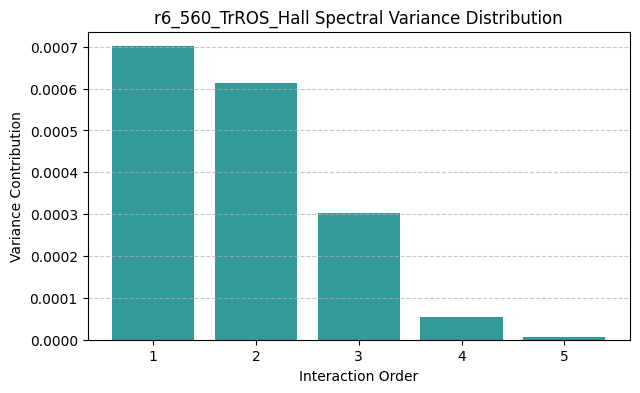

In [ ]:
names = ['1F0M', '2KRU', '2L09', '2LVN', '2M2J', '2MA4', '4G3O', '5JRT', '7JJK', 'HEEH_KT_rd6_0746', 'r6_560_TrROS_Hall']
times = ['20260428-013719', '20260428-043722', '20260428-012947', '20260428-030742', '20260428-023032', '20260428-034602', '20260428-021920', '20260428-024054', '20260428-034159', '20260428-011444', '20260428-002915']

for n, t in zip(names, times):
    display_time(n, t)

In [ ]:
# Export merged variance + sparsity strips for Neurips paper (two-panel PDFs per protein).
OUT = "/home/shai/NeuripsProtein2026/Figures"
os.makedirs(OUT, exist_ok=True)
display_time(
    "r6_560_TrROS_Hall",
    "20260428-002915",
    save_path=os.path.join(OUT, "r6_560_trros_hall_spex_merged.pdf"),
)
display_time(
    "2KRU",
    "20260428-043722",
    save_path=os.path.join(OUT, "2kru_spex_merged.pdf"),
)
print("Wrote:", OUT)